In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.rename(columns={"MedHouseVal": "Target"}, inplace=True)

print("Description du DataFrame")
df.info()

print("`\nPremières lignes")
df.head()

Description du DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
`
Premières lignes


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
print(df.isnull().sum())

print(f"\nNombre total de valeurs manquantes: {df.isnull().sum().sum()}")

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

Nombre total de valeurs manquantes: 0


In [6]:
# Features
X = df.drop("Target", axis=1)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [86]:
# Target
y = df["Target"].to_frame()
y

,Target
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


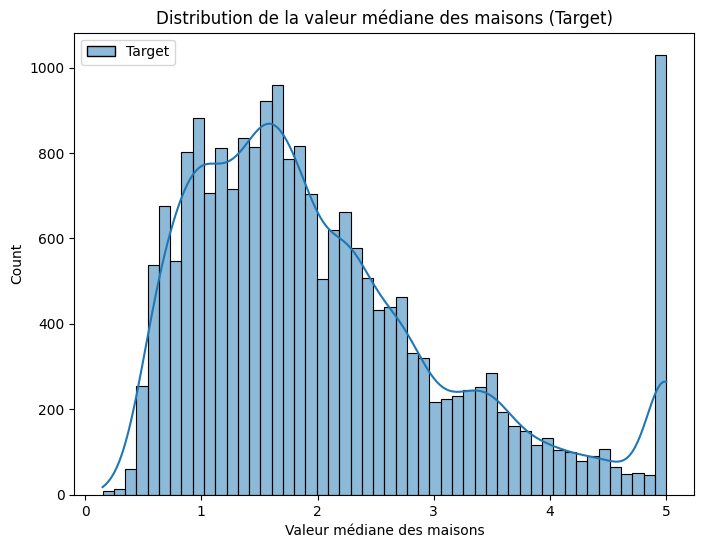

In [22]:
plt.figure(figsize=(8, 6))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution de la valeur médiane des maisons (Target)")
plt.xlabel("Valeur médiane des maisons")
plt.show()

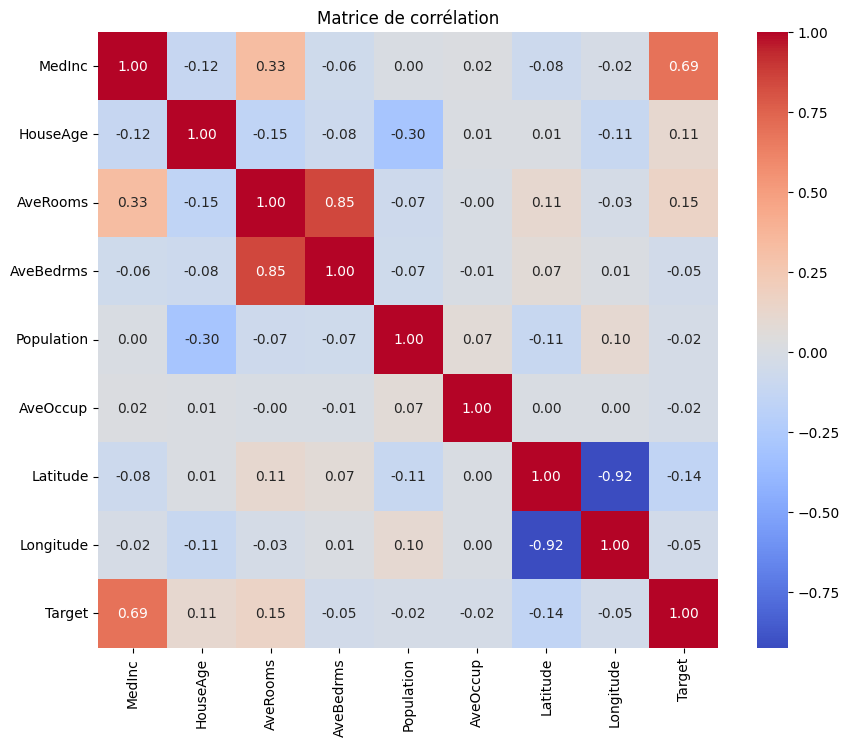

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
X["RoomsPerHousehold"] = X["AveRooms"] / X["AveOccup"]
X["BedroomsPerRoom"] = X["AveBedrms"] / X["AveRooms"]
X["PopulationPerHousehold"] = X["Population"] / X["AveOccup"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test, columns=X_test.columns)

print("Échelle des données après standardisation (premières lignes):")
X_train_scaled.head()

Échelle des données après standardisation (premières lignes):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.359130,0.200576,623.0
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,2.573820,0.232703,756.0
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,2.073224,0.174486,336.0
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,1.002116,0.258269,355.0
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,2.725400,0.180940,380.0


In [88]:
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, np.array(y_train).ravel())

importances = rf_selector.feature_importances_

feature_importance_df = pd.DataFrame(
    {"Feature": X_train_scaled.columns, "Importance": importances}
).sort_values(by="Importance", ascending=False)


feature_importance_df.head()

,Feature,Importance
0,MedInc,0.521127
5,AveOccup,0.126772
6,Latitude,0.082825
7,Longitude,0.082766
1,HouseAge,0.051766


In [13]:
# 1er modèle
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
# 2ème modèle
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_reg.fit(X_train_scaled, np.array(y_train).ravel())

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred_lin = lin_reg.predict(X_test_scaled)
y_pred_forest = forest_reg.predict(X_test_scaled)

# Evaluation Régression linéaire
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)

# Evaluation Forêt Aléatoire
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)

print(f"[Régression Linéaire] RMSE: {rmse_lin:.4f}")
print(f"[Forêt Aléatoire] RMSE: {rmse_forest:.4f}")

[Régression Linéaire] RMSE: 0.6738
[Forêt Aléatoire] RMSE: 0.5061


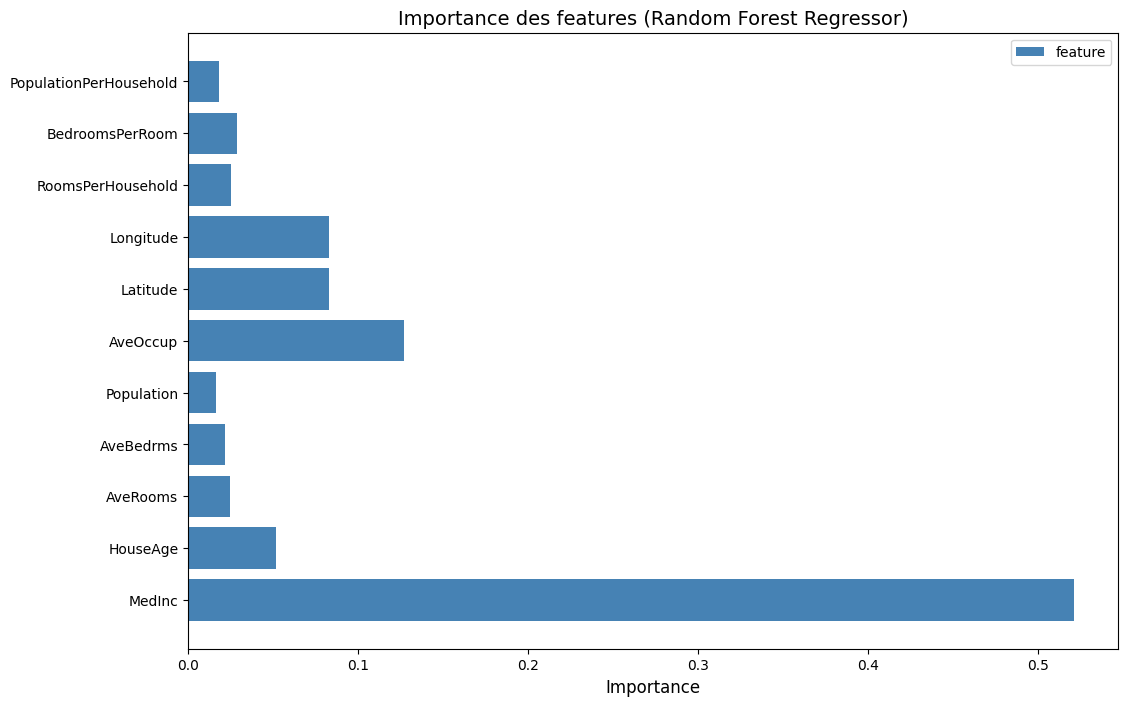

In [ ]:
importances_final = forest_reg.feature_importances_

feature_importance_df = pd.DataFrame(
    {"Feature": X_train_scaled.columns, "Importance": importances_final}
)

plt.figure(figsize=(12, 8))
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"],
    color="steelblue",
    label="feature"
)
plt.xlabel("Importance", fontsize=12)
plt.title("Importance des features (Random Forest Regressor)", fontsize=14)
plt.legend()
plt.show()

In [17]:
joblib.dump(forest_reg, "random_forest_regressor.pkl")

print("Modèle 'random_forest_regressor.pkl' sauvergardé.")

Modèle 'random_forest_regressor.pkl' sauvergardé.


In [93]:
loaded_model = joblib.load("./random_forest_regressor.pkl")
print(
    f"Modèle chargé. Test de prédiction sur le premier élément du test: {loaded_model.predict(X_test.iloc[0, ].to_frame().T)[0]:.6f}"
)

Modèle chargé. Test de prédiction sur le premier élément du test: 0.477550


In [94]:
data = np.concatenate(([X_test.values[0]], [y_test.values[0]]), axis=1)
colonnes = np.concatenate((loaded_model.feature_names_in_, "Target"), axis=None)

print("Premier élément test : ")
pd.DataFrame(data, columns=colonnes)

Premier élément test : 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold,Target
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,1.081178,0.243854,359.0,0.477
